In [21]:
import numpy as np
import pandas as pd
import torch
import hydra
import matplotlib.pyplot as plt

from pathlib import Path
from omegaconf import OmegaConf
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.linear_model import LogisticRegression, Ridge

from toy_disentanglement.task import create_embedding_autoencoder, LatentClassificationDataset
from toy_disentanglement.metrics import classification_generalization_accuracy, regression_generalization_r2, representation_intrinsic_dimension

## Load all corresponding runs

In [2]:
def flatten_dict(d, sep='.'):
    """Recursively flattens a nested dictionary."""
    items = []
    for k, v in d.items():
        new_key = k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def get_sweep_runs(sweep_id: int, run_dir: Path = Path("../runs/")):
    run_info = []
    for run in run_dir.iterdir():
        if not run.is_dir():
            continue
        if not (run / "config.yaml").exists():
            continue
        config = OmegaConf.load(run / "config.yaml")
        if config.get("sweep_id", None) == sweep_id:
            flat_config = flatten_dict(OmegaConf.to_container(config))
            run_info.append(
                {
                    **{k: v for k, v in flat_config.items() if ('$' not in str(v))},
                    "run_name": run.name,
                }
            )
    return pd.DataFrame(run_info)

In [3]:
run_df = get_sweep_runs(sweep_id=1)

In [5]:
run_df['depth'] = run_df['hidden_dims'].apply(lambda x: len(x))

## Show 

In [22]:
results = []

for row in run_df.itertuples():
    checkpoint_path = Path("../runs/") / row.run_name / "checkpoints" / "checkpoint_final.pt"

    config_path = Path("../runs/") / row.run_name / "config.yaml"
    with hydra.initialize(str(config_path.parent)):
        config = OmegaConf.load(config_path)
        latent_dim = config.dataset.latent_dim
        embedding_net = hydra.utils.instantiate(config.embedding)
        model = hydra.utils.instantiate(config.model)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
    
    data_dist = torch.distributions.normal.Normal(loc=torch.zeros(latent_dim), scale=torch.ones(latent_dim))
    test_acc = classification_generalization_accuracy(
        rep_fn=model.get_all_layer_representations,
        embed_fn=embedding_net.encoder,
        data_dist=data_dist,
        num_tasks=50,
        bias=True,
    )[1]
    test_r2 = regression_generalization_r2(
        rep_fn=model.get_all_layer_representations,
        embed_fn=embedding_net.encoder,
        data_dist=data_dist,
        num_tasks=50,
    )[1]
    intrinsic_dimensions = representation_intrinsic_dimension(
        rep_fn=model.get_all_layer_representations,
        embed_fn=embedding_net.encoder,
        data_dist=data_dist,
    )
    test_acc = np.nanmean(test_acc, axis=0)
    test_r2 = np.nanmean(test_r2, axis=0)

    results.append(dict(
        run_name=row.run_name, 
        depth=row.depth, 
        num_tasks=row.num_tasks, 
        test_acc_last=test_acc[-1], 
        test_r2_last=test_r2[-1],
        intrinsic_dim_last=intrinsic_dimensions[-1],
        test_acc=test_acc.tolist(),
        test_r2=test_r2.tolist(),
        intrinsic_dims=intrinsic_dimensions.tolist(),
    ))

results = pd.DataFrame(results)


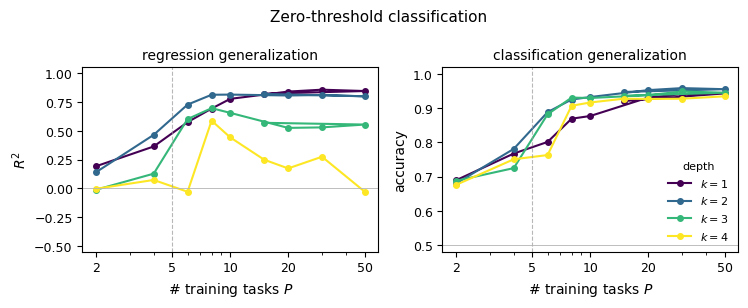

In [20]:
num_depths = results['depth'].nunique()
def depth_colors():
    cmap = plt.get_cmap("viridis")
    colors = {k: cmap(i / (num_depths - 1)) for i, k in enumerate(sorted(results['depth'].unique()))}
    return colors

colors = depth_colors()
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.1))

for idx, group in results.groupby("depth"):
    xs = group.num_tasks.tolist()
    r2s = group.test_r2_last.tolist()
    accs = group.test_acc_last.tolist()
    axes[0].plot(xs, r2s, marker="o", ms=4, color=colors[idx], label=f"$k = {idx}$")
    axes[1].plot(xs, accs, marker="o", ms=4, color=colors[idx], label=f"$k = {idx}$")

for ax in axes:
    ax.axvline(5, color="0.6", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_xlabel("# training tasks $P$")
    ax.set_xscale("log")
    ax.set_xticks([2, 5, 10, 20, 50])
    ax.set_xticklabels(["2", "5", "10", "20", "50"])
    ax.tick_params(axis="both", labelsize=9)
axes[0].set_title("regression generalization", fontsize=10)
axes[0].set_ylabel(r"$R^2$")
axes[0].set_ylim(-0.55, 1.05)
axes[0].axhline(0, color="0.7", linewidth=0.6)
axes[1].set_title("classification generalization", fontsize=10)
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.48, 1.02)
axes[1].axhline(0.5, color="0.7", linewidth=0.6)

axes[1].legend(loc="lower right", fontsize=8, frameon=False, title="depth", title_fontsize=8)
fig.suptitle("Zero-threshold classification", fontsize=11)
fig.tight_layout()
fig.savefig("../plots/figures/unbiased.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

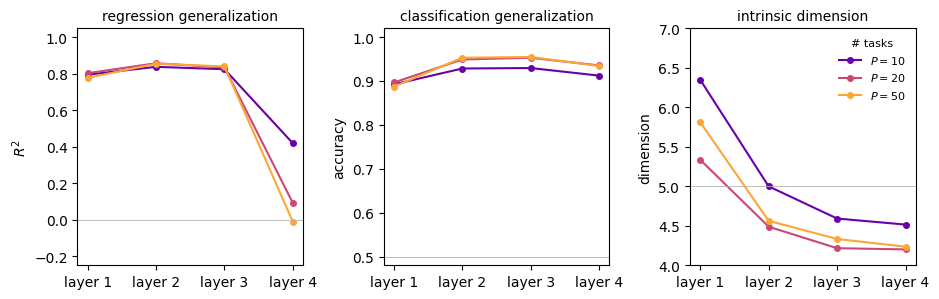

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.1))

num_tasks = [10, 20, 50]
colors = [plt.cm.plasma(0.2), plt.cm.plasma(0.5), plt.cm.plasma(0.8), plt.cm.plasma(0.95)]

for num_task, color in zip(num_tasks, colors):
    run_metrics = results[(results.depth == 4) & (results.num_tasks == num_task)]
    xs = np.arange(4)
    r2s = run_metrics.test_r2.tolist()
    accs = run_metrics.test_acc.tolist()
    intrinsic_dims = run_metrics.intrinsic_dims.tolist()

    axes[0].plot(xs, r2s[0], marker="o", ms=4, color=color, label=f"$P = {num_task}$")
    axes[1].plot(xs, accs[0], marker="o", ms=4, color=color, label=f"$P = {num_task}$")
    axes[2].plot(xs, intrinsic_dims[0], marker="o", ms=4, color=color, label=f"$P = {num_task}$")
axes[0].set_title("regression generalization", fontsize=10)
axes[0].set_ylabel(r"$R^2$")
axes[0].set_xticks(xs)
axes[0].set_xticklabels([f"layer {i+1}" for i in xs])
axes[0].set_ylim(-0.25, 1.05)
axes[0].axhline(0, color="0.7", linewidth=0.6)
axes[1].set_title("classification generalization", fontsize=10)
axes[1].set_ylabel("accuracy")
axes[1].set_xticks(xs)
axes[1].set_xticklabels([f"layer {i+1}" for i in xs])
axes[1].set_ylim(0.48, 1.02)
axes[1].axhline(0.5, color="0.7", linewidth=0.6)
axes[2].set_title("intrinsic dimension", fontsize=10)
axes[2].set_ylabel("dimension")
axes[2].set_xticks(xs)
axes[2].set_xticklabels([f"layer {i+1}" for i in xs])
axes[2].set_ylim(4.0, 7.0)
axes[2].axhline(5.0, color="0.7", linewidth=0.6)
# axes[2].set_ylim(0, 20)

axes[2].legend(loc="upper right", fontsize=8, frameon=False, title="# tasks", title_fontsize=8)
# fig.suptitle("Zero-threshold classification", fontsize=11)
fig.tight_layout()
fig.savefig("../plots/figures/unbiased_per_layer.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

In [21]:
config_path = Path("../runs/") / run_name / "config.yaml"
with hydra.initialize(str(config_path.parent)):
    config = OmegaConf.load(config_path)
    latent_dim = config.dataset.latent_dim
    embedding_net = hydra.utils.instantiate(config.embedding)
    model = hydra.utils.instantiate(config.model)
    model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))

In [22]:
data_dist = torch.distributions.normal.Normal(loc=torch.zeros(latent_dim), scale=torch.ones(latent_dim))

In [23]:
samples = data_dist.sample((1000,))
with torch.no_grad():
    embeddings = embedding_net.encoder(samples)
representation = model.get_all_layer_representations(embeddings)

In [26]:
final_representation = representation[-1].numpy()

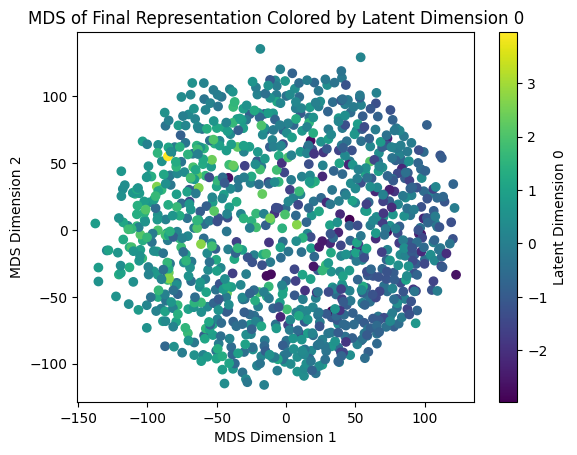

In [ ]:
mds = MDS(n_components=2)
mds_embedding = mds.fit_transform(final_representation)

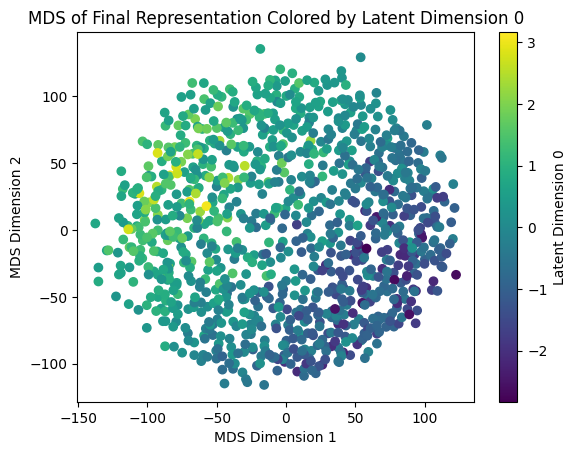

In [37]:
plt.scatter(mds_embedding[:, 0], mds_embedding[:, 1], c=samples[:, 4].numpy(), cmap='viridis')
plt.colorbar(label='Latent Dimension 0')
plt.title('MDS of Final Representation Colored by Latent Dimension 0')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.show()